In [ ]:
import subprocess, sys
def pip(*pkgs):
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *pkgs], check=False)
pip("graphifyy[sql]", "pyvis", "networkx", "matplotlib")

import os, json, glob, textwrap, warnings
import networkx as nx
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")

In [ ]:
ROOT = "sample_app"
os.makedirs(ROOT, exist_ok=True)

FILES = {
"config.py": '''
# Central settings object — used everywhere (expect this to be a "god node").
class Settings:
    def __init__(self):
        self.db_dsn = "postgresql://localhost/app"
        self.jwt_secret = "change-me"
        self.rate_limit = 100

settings = Settings()
''',

"database.py": '''
from config import settings

class DatabasePool:
    """Connection pool. WHY: reuse sockets instead of reconnecting per query."""
    def __init__(self, dsn):
        self.dsn = dsn
        self._conns = []

    def acquire(self):
        return {"dsn": self.dsn}

pool = DatabasePool(settings.db_dsn)

def get_connection():
    return pool.acquire()
''',

"models.py": '''
class User:
    def __init__(self, user_id, email):
        self.user_id = user_id
        self.email = email

class Session:
    def __init__(self, user, token):
        self.user = user
        self.token = token
''',

"cache.py": '''
from config import settings

class RateLimiter:
    # NOTE: naive in-memory limiter; swap for Redis in prod.
    def __init__(self, limit):
        self.limit = limit
        self.hits = {}

    def allow(self, key):
        self.hits[key] = self.hits.get(key, 0) + 1
        return self.hits[key] <= self.limit

limiter = RateLimiter(settings.rate_limit)
''',

"auth.py": '''
from config import settings
from database import get_connection
from models import User, Session

def hash_password(raw):
    return f"hashed::{raw}"

def verify_password(raw, hashed):
    return hash_password(raw) == hashed

class AuthService:
    def __init__(self):
        self.secret = settings.jwt_secret

    def login(self, email, password):
        conn = get_connection()
        user = User(user_id=1, email=email)
        return Session(user=user, token=self.secret + email)
''',

"services.py": '''
from database import get_connection
from models import User
from auth import AuthService

class UserService:
    def __init__(self):
        self.auth = AuthService()

    def register(self, email, password):
        conn = get_connection()
        return User(user_id=2, email=email)

    def authenticate(self, email, password):
        return self.auth.login(email, password)
''',

"api.py": '''
from cache import limiter
from services import UserService
from auth import verify_password

svc = UserService()

def signup_route(email, password):
    if not limiter.allow(email):
        return {"error": "rate limited"}
    return svc.register(email, password)

def login_route(email, password):
    if not limiter.allow(email):
        return {"error": "rate limited"}
    return svc.authenticate(email, password)
''',

"main.py": '''
from api import signup_route, login_route
from database import pool

def run():
    signup_route("a@x.com", "pw")
    return login_route("a@x.com", "pw")

if __name__ == "__main__":
    run()
''',

"schema.sql": '''
CREATE TABLE users (
    user_id  SERIAL PRIMARY KEY,
    email    TEXT UNIQUE NOT NULL
);

CREATE TABLE sessions (
    token    TEXT PRIMARY KEY,
    user_id  INTEGER NOT NULL REFERENCES users(user_id)
);

CREATE VIEW active_sessions AS
SELECT s.token, u.email
FROM sessions s JOIN users u ON s.user_id = u.user_id;
''',
}

for name, body in FILES.items():
    with open(os.path.join(ROOT, name), "w") as f:
        f.write(textwrap.dedent(body).lstrip())
print(f"Wrote {len(FILES)} files to ./{ROOT}/")

In [ ]:
res = subprocess.run(
    [sys.executable, "-m", "graphify", "extract", ROOT, "--no-cluster"],
    capture_output=True, text=True
)
print(res.stdout[-1500:] or res.stderr[-1500:])

graph_paths = glob.glob("**/graph.json", recursive=True)
assert graph_paths, "graph.json not found — check the extract output above."
GRAPH_JSON = sorted(graph_paths, key=os.path.getmtime)[-1]
print("Graph file:", GRAPH_JSON)

def load_graphify(path):
    data = json.load(open(path))
    ekey = "links" if "links" in data else ("edges" if "edges" in data else None)
    G = nx.DiGraph() if data.get("directed") else nx.Graph()
    for n in data.get("nodes", []):
        nid = n.get("id")
        G.add_node(nid, **{k: v for k, v in n.items() if k != "id"})
    for e in data.get(ekey or "links", []):
        G.add_edge(e.get("source"), e.get("target"),
                   **{k: v for k, v in e.items() if k not in ("source", "target")})
    G.graph.update(data.get("graph", {}))
    return G

G = load_graphify(GRAPH_JSON)
UG = G.to_undirected()
print(f"\nGraph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

def label(n):
    return G.nodes[n].get("label", str(n))

In [ ]:
from collections import Counter
ftypes  = Counter(d.get("file_type", "?") for _, d in G.nodes(data=True))
rels    = Counter(d.get("relation", "?")  for *_ , d in G.edges(data=True))
conf    = Counter(d.get("confidence", "?") for *_ , d in G.edges(data=True))
print("\nNodes by file_type :", dict(ftypes))
print("Edges by relation  :", dict(rels))
print("Edges by confidence:", dict(conf))

deg = nx.degree_centrality(UG)
btw = nx.betweenness_centrality(UG)
print("\nTop 'god nodes' by degree centrality:")
for n, c in sorted(deg.items(), key=lambda x: -x[1])[:8]:
    print(f"  {label(n):<22} deg={c:.3f}  betweenness={btw.get(n,0):.3f}")

try:
    communities = nx.community.louvain_communities(UG, seed=42)
except Exception:
    communities = list(nx.community.greedy_modularity_communities(UG))
node_comm = {n: i for i, com in enumerate(communities) for n in com}
print(f"\nDetected {len(communities)} communities:")
for i, com in enumerate(communities):
    members = ", ".join(sorted(label(n) for n in com))[:90]
    print(f"  Community {i}: {members}")

def find(substr):
    for n in G.nodes:
        if substr.lower() in label(n).lower():
            return n
    return None
a, b = find("api"), find("DatabasePool")
if a and b and nx.has_path(UG, a, b):
    path = nx.shortest_path(UG, a, b)
    print(f"\nPath {label(a)} -> {label(b)}:")
    print("   " + "  →  ".join(label(p) for p in path))

Wrote 9 files to ./sample_app/
[graphify extract] scanning /content/sample_app
[graphify extract] found 9 code, 0 docs, 0 papers, 0 images
[graphify extract] AST extraction on 9 code files...
[graphify extract] wrote /content/sample_app/graphify-out/graph.json — 39 nodes, 70 edges (no clustering)

Graph file: sample_app/graphify-out/graph.json

Graph: 39 nodes, 70 edges

Nodes by file_type : {'code': 37, 'rationale': 2}
Edges by relation  : {'imports_from': 13, 'contains': 16, 'imports': 10, 'calls': 10, 'method': 12, 'uses': 4, 'rationale_for': 2, 'references': 1, 'reads_from': 2}
Edges by confidence: {'EXTRACTED': 66, 'INFERRED': 4}

Top 'god nodes' by degree centrality:
  auth.py                deg=0.289  betweenness=0.241
  api.py                 deg=0.211  betweenness=0.220
  AuthService            deg=0.211  betweenness=0.086
  User                   deg=0.211  betweenness=0.069
  services.py            deg=0.211  betweenness=0.079
  UserService            deg=0.184  betweenness=

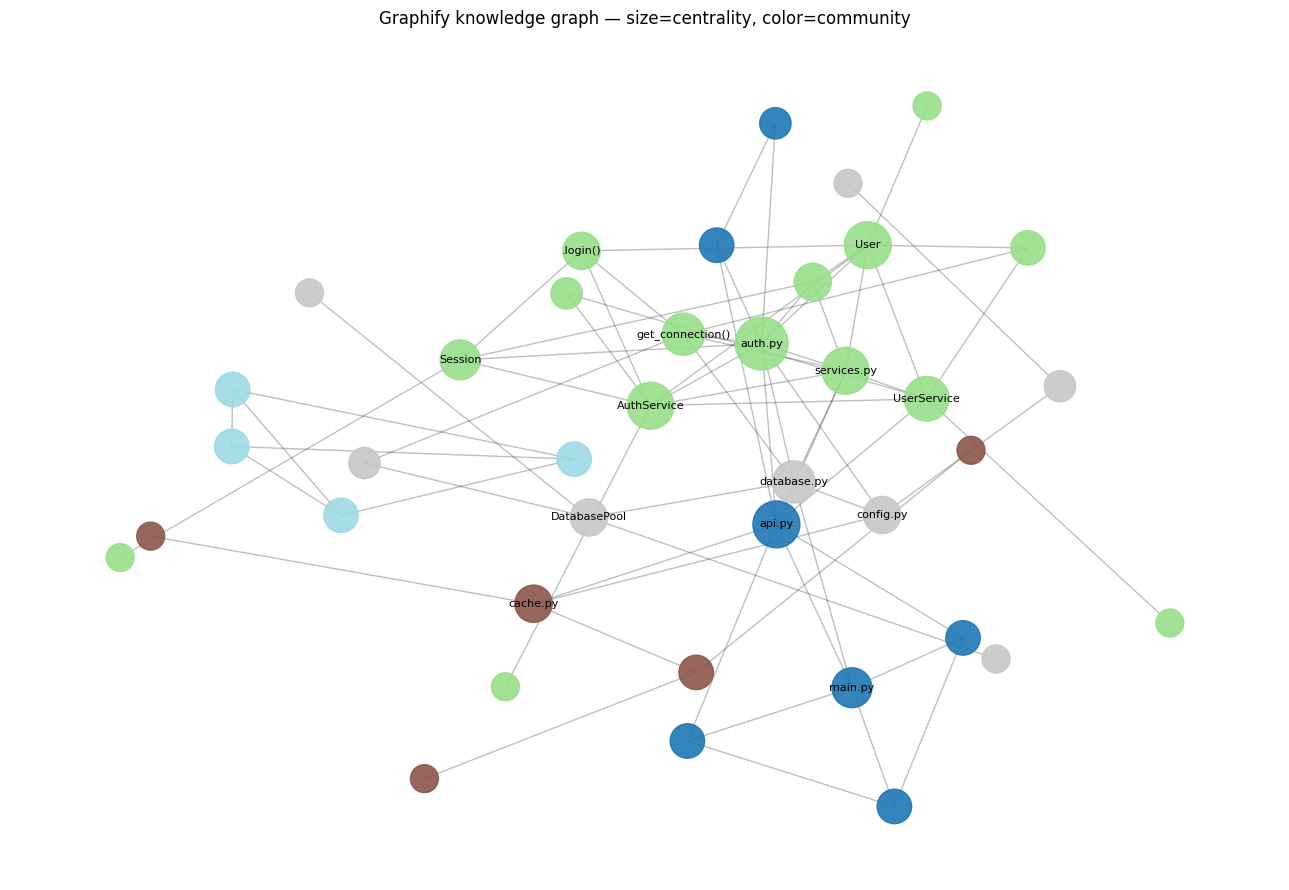


Saved interactive graph -> graph_interactive.html



$ graphify query what connects auth to the database? --graph sample_app/graphify-out/graph.json
Traversal: BFS depth=2 | Start: ['database.py', 'DatabasePool', 'auth.py'] | 29 nodes found

NODE auth.py [src=auth.py loc=L1 community=]
NODE api.py [src=api.py loc=L1 community=]
NODE User [src=models.py loc=L1 community=]
NODE AuthService [src=auth.py loc=L11 community=]
NODE services.py [src=services.py loc=L1 community=]
NODE UserService [src=services.py loc=L5 community=]
NODE get_connection() [src=database.py loc=L14 community=]
NODE database.py [src=database.py loc=L1 community=]
NODE main.py [src=main.py loc=L1 community=]
NODE Session [src=models.py loc=L6 community=]
NODE models.py [src=models.py loc=L1 community=]
NODE config.py [src=config.py loc=L1 community=]
NODE cache.py [src=cache.py loc=L1 community=]
NODE DatabasePool [src=database.py loc=L3 community=]
NODE .login() [src=auth.py loc=L15 community=]
NODE login_route() [src=api.py loc=L12 community=]
NODE signup_route() [

In [1]:
plt.figure(figsize=(13, 9))
pos = nx.spring_layout(UG, k=0.7, seed=42)
nx.draw_networkx_edges(UG, pos, alpha=0.25)
nx.draw_networkx_nodes(
    UG, pos,
    node_color=[node_comm.get(n, 0) for n in UG.nodes],
    node_size=[300 + 4000 * deg.get(n, 0) for n in UG.nodes],
    cmap=plt.cm.tab20, alpha=0.9,
)
top = {n for n, _ in sorted(deg.items(), key=lambda x: -x[1])[:14]}
nx.draw_networkx_labels(UG, pos, {n: label(n) for n in top}, font_size=8)
plt.title("Graphify knowledge graph — size=centrality, color=community")
plt.axis("off"); plt.tight_layout()
plt.savefig("graph_static.png", dpi=130); plt.show()

try:
    from pyvis.network import Network
    net = Network(height="650px", width="100%", bgcolor="#111", font_color="white",
                  notebook=True, cdn_resources="in_line", directed=G.is_directed())
    palette = ["#e6194B","#3cb44b","#4363d8","#f58231","#911eb4",
               "#42d4f4","#f032e6","#bfef45","#fabed4","#469990"]
    for n, d in G.nodes(data=True):
        c = node_comm.get(n, 0)
        net.add_node(n, label=label(n), title=f"{d.get('file_type','?')} · {d.get('source_file','')}",
                     color=palette[c % len(palette)], size=12 + 60 * deg.get(n, 0))
    for s, t, d in G.edges(data=True):
        net.add_edge(s, t, title=d.get("relation", ""))
    net.save_graph("graph_interactive.html")
    print("\nSaved interactive graph -> graph_interactive.html")
    from IPython.display import HTML, display
    display(HTML(open("graph_interactive.html").read()))
except Exception as e:
    print("Interactive viz skipped:", e)

for cmd in (
    ["query", "what connects auth to the database?", "--graph", GRAPH_JSON],
    ["path",  "AuthService", "DatabasePool", "--graph", GRAPH_JSON],
    ["explain", "RateLimiter", "--graph", GRAPH_JSON],
):
    print("\n$ graphify " + " ".join(cmd))
    r = subprocess.run([sys.executable, "-m", "graphify", *cmd],
                       capture_output=True, text=True)
    print((r.stdout or r.stderr)[:1200])

print("\nDone. Artifacts: graph_static.png, graph_interactive.html,",
      "and graphify-out/ (graph.json, GRAPH_REPORT.md).")